# Priced Out: Mapping the ACA Coverage Collapse Across U.S. States (2025-2026)

This notebook analyzes CMS Open Enrollment Period data for 2025 and 2026 across
all 51 states to identify where ACA marketplace enrollment collapsed, how remaining
enrollees are responding, and which states face the highest exposure to future
coverage loss.

**Data Sources:**
- CMS OEP State-Level Public Use Files (2025 and 2026)
- Census Household Pulse Survey Cycle 09 (2024)

**1.File upload**

In [ ]:
from google.colab import files
uploaded = files.upload()
print('Files uploaded:', list(uploaded.keys()))

Saving spending1_cycle09.xlsx to spending1_cycle09.xlsx
Saving food1_cycle09.xlsx to food1_cycle09.xlsx
Saving 2025 OEP State-Level Public Use File.csv to 2025 OEP State-Level Public Use File.csv
Saving 2026 OEP State-Level Public Use File.csv to 2026 OEP State-Level Public Use File (1).csv
Files uploaded: ['spending1_cycle09.xlsx', 'food1_cycle09.xlsx', '2025 OEP State-Level Public Use File.csv', '2026 OEP State-Level Public Use File (1).csv']


**2. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import zipfile
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ✅')

Libraries loaded ✅


**3.State Reference Table**

In [ ]:
state_name_to_abbr = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','District of Columbia':'DC',
    'Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID','Illinois':'IL',
    'Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA',
    'Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN',
    'Mississippi':'MS','Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV',
    'New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM','New York':'NY',
    'North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK','Oregon':'OR',
    'Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
    'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA',
    'Washington':'WA','West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}
abbr_to_name = {v:k for k,v in state_name_to_abbr.items()}
states_list = list(abbr_to_name.keys())

print(f'{len(states_list)} states + DC loaded ✅')

51 states + DC loaded ✅


**4.Helper functions**

In [ ]:
ns = {'ns': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

def clean_num(series):
    """Strip commas and dollar signs, convert to numeric."""
    return pd.to_numeric(
        series.astype(str).str.replace(',', '').str.replace('$', '').str.strip(),
        errors='coerce'
    )

def get_strings(zf):
    """Extract shared string table from xlsx."""
    with zf.open('xl/sharedStrings.xml') as f:
        root = ET.parse(f).getroot()
    return [
        si.find('.//ns:t', ns).text if si.find('.//ns:t', ns) is not None else ''
        for si in root.findall('ns:si', ns)
    ]

def get_sheet_map(zf):
    """Map sheet names to their XML file paths inside the xlsx."""
    with zf.open('xl/workbook.xml') as f:
        root = ET.parse(f).getroot()
    sheets = root.findall('.//ns:sheet', ns)
    with zf.open('xl/_rels/workbook.xml.rels') as f:
        root2 = ET.parse(f).getroot()
    rels = {
        r.get('Id'): r.get('Target')
        for r in root2.findall(
            './/{http://schemas.openxmlformats.org/package/2006/relationships}Relationship'
        )
    }
    return {
        s.get('name'): rels.get(
            s.get('{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id')
        )
        for s in sheets
    }

def read_state_rows(zf, sheet_file, strings):
    """Read all data rows from a single state sheet."""
    with zf.open('xl/' + sheet_file) as f:
        root = ET.parse(f).getroot()
    result = []
    for row in root.findall('.//ns:row', ns):
        cells = row.findall('ns:c', ns)
        row_data = []
        for c in cells:
            t = c.get('t', '')
            v = c.find('ns:v', ns)
            row_data.append(
                strings[int(v.text)] if v is not None and t == 's'
                else (v.text if v is not None else '')
            )
        if any(x for x in row_data if x):
            result.append(row_data)
    return result

print('Helper functions ready ✅')

Helper functions ready ✅


**5.Load and clean CMS data**

In [ ]:
print('CLEANING LOG-')

# Load raw files
cms25_raw = pd.read_csv('2025 OEP State-Level Public Use File.csv')
cms26_raw = pd.read_csv('2026 OEP State-Level Public Use File (1).csv')
print('CMS 2025 raw:', len(cms25_raw), 'rows')
print('CMS 2026 raw:', len(cms26_raw), 'rows')

# Drop blank trailing rows in CMS 2026
cms26_raw = cms26_raw.dropna(subset=['State_Abrvtn'])
print('CMS 2026 after dropping blank rows:', len(cms26_raw), 'rows')

# Remove summary rows
cms25 = cms25_raw[
    (cms25_raw['Pltfrm'] != 'All') &
    (cms25_raw['State_Abrvtn'] != 'Total')
].copy()

cms26 = cms26_raw[
    (cms26_raw['Pltfrm'] != 'All') &
    (cms26_raw['State_Abrvtn'] != 'Total') &
    (cms26_raw['Pltfrm'].notna())
].copy()

print('CMS 2025 state rows:', len(cms25), '(expected 51)')
print('CMS 2026 state rows:', len(cms26), '(expected 51)')

# Clean numeric columns
cols_to_clean = [
    'Cnsmr', 'New_Cnsmr', 'APTC_Cnsmr', 'Avg_Prm', 'Avg_Prm_Aftr_APTC',
    'Brnz', 'Slvr', 'Gld', 'Pltnm',
    'FPL_LT100', 'FPL_100_138', 'FPL_150_200', 'FPL_200_250',
    'FPL_300_400', 'FPL_400_500', 'FPL_GT500',
    'Age_0_17', 'Age_18_25', 'Age_26_34', 'Age_35_44', 'Age_45_54', 'Age_55_64',
    'Rrl', 'Non_Rrl'
]

for col in cols_to_clean:
    if col in cms25.columns:
        cms25[col] = clean_num(cms25[col])
    if col in cms26.columns:
        cms26[col] = clean_num(cms26[col])

print('Rural data available for', cms25['Rrl'].notna().sum(), 'of 51 states')
print('Nulls after cleaning:', cms25[cols_to_clean].isnull().sum().sum(), '(all rural suppression)')
print()


CLEANING LOG-
CMS 2025 raw: 54 rows
CMS 2026 raw: 58 rows
CMS 2026 after dropping blank rows: 54 rows
CMS 2025 state rows: 51 (expected 51)
CMS 2026 state rows: 51 (expected 51)
Rural data available for 31 of 51 states
Nulls after cleaning: 71 (all rural suppression)



**6. Load HPS supporting data**

In [ ]:
food_data = {}
with zipfile.ZipFile('food1_cycle09.xlsx') as z:
    strings = get_strings(z)
    sheet_map = get_sheet_map(z)
    for state in states_list:
        for row in read_state_rows(z, sheet_map[state], strings):
            if row and row[0] == 'Total' and len(row) >= 3:
                try:
                    total = float(row[1])
                    enough = float(row[2])
                    food_data[state] = round(((total - enough) / total) * 100, 2)
                except:
                    pass
                break

spend_data = {}
with zipfile.ZipFile('spending1_cycle09.xlsx') as z:
    strings = get_strings(z)
    sheet_map = get_sheet_map(z)
    for state in states_list:
        for row in read_state_rows(z, sheet_map[state], strings):
            if row and row[0] == 'Total' and len(row) >= 6:
                try:
                    total = float(row[1])
                    somewhat = float(row[4]) if row[4] else 0
                    very = float(row[5]) if row[5] else 0
                    spend_data[state] = round(((somewhat + very) / total) * 100, 2)
                except:
                    pass
                break

print('Food data:', len(food_data), 'states')
print('Spending data:', len(spend_data), 'states')


Food data: 51 states
Spending data: 51 states


**7.Build master dataset**

In [ ]:
# Merge CMS 2025 and 2026
master = cms25[['State_Abrvtn'] + [c for c in cols_to_clean if c in cms25.columns]].merge(
    cms26[['State_Abrvtn'] + [c for c in cols_to_clean if c in cms26.columns]],
    on='State_Abrvtn',
    suffixes=('_25', '_26')
)

master['state_name'] = master['State_Abrvtn'].map(abbr_to_name)

# ENROLLMENT CHANGE
master['enrl_drop_pct'] = round(
    ((master['Cnsmr_26'] - master['Cnsmr_25']) / master['Cnsmr_25']) * 100, 2)
master['enrl_lost'] = (master['Cnsmr_25'] - master['Cnsmr_26']).astype(int)

# SUBSIDY DEPENDENCY
master['aptc_rate_2025'] = round(master['APTC_Cnsmr_25'] / master['Cnsmr_25'] * 100, 1)
master['aptc_rate_2026'] = round(master['APTC_Cnsmr_26'] / master['Cnsmr_26'] * 100, 1)
master['aptc_change']    = round(master['aptc_rate_2026'] - master['aptc_rate_2025'], 1)

# PREMIUM AFFORDABILITY
master['avg_prm_2025']              = master['Avg_Prm_25']
master['avg_prm_2026']              = master['Avg_Prm_26']
master['premium_change']            = round(master['Avg_Prm_26'] - master['Avg_Prm_25'], 0)
master['avg_prm_after_aptc_2025']   = master['Avg_Prm_Aftr_APTC_25']
master['avg_prm_after_aptc_2026']   = master['Avg_Prm_Aftr_APTC_26']
master['premium_after_aptc_change'] = round(
    master['Avg_Prm_Aftr_APTC_26'] - master['Avg_Prm_Aftr_APTC_25'], 0)

# PLAN TYPE SHIFT
master['bronze_pct_2025'] = round(master['Brnz_25'] / master['Cnsmr_25'] * 100, 1)
master['bronze_pct_2026'] = round(master['Brnz_26'] / master['Cnsmr_26'] * 100, 1)
master['bronze_shift']    = round(master['bronze_pct_2026'] - master['bronze_pct_2025'], 1)
master['silver_pct_2025'] = round(master['Slvr_25'] / master['Cnsmr_25'] * 100, 1)
master['silver_pct_2026'] = round(master['Slvr_26'] / master['Cnsmr_26'] * 100, 1)
master['silver_shift']    = round(master['silver_pct_2026'] - master['silver_pct_2025'], 1)

# DEMOGRAPHICS
master['rural_pct']      = round(
    master['Rrl_25'] / (master['Rrl_25'] + master['Non_Rrl_25']) * 100, 1)
master['low_income_pct'] = round(
    (master['FPL_100_138_25'] + master['FPL_150_200_25']) / master['Cnsmr_25'] * 100, 1)
master['new_enrollee_pct_2025'] = round(master['New_Cnsmr_25'] / master['Cnsmr_25'] * 100, 1)
master['new_enrollee_pct_2026'] = round(master['New_Cnsmr_26'] / master['Cnsmr_26'] * 100, 1)

# HPS SUPPORTING DATA
master['food_insuff_pct']  = master['State_Abrvtn'].map(food_data)
master['spend_stress_pct'] = master['State_Abrvtn'].map(spend_data)

print('Master dataset:', master.shape[0], 'states,', master.shape[1], 'columns')
print('Nulls in key metrics:', master[['enrl_drop_pct','aptc_rate_2025','bronze_shift','premium_change']].isnull().sum().sum())
print()
print('Top 5 states by enrollment drop:')
print(master.sort_values('enrl_drop_pct')[['State_Abrvtn','enrl_drop_pct','bronze_shift','aptc_rate_2025']].head())
print()


Master dataset: 51 states, 73 columns
Nulls in key metrics: 0

Top 5 states by enrollment drop:
   State_Abrvtn  enrl_drop_pct  bronze_shift  aptc_rate_2025
27           NC         -21.91          18.5            94.3
35           OH         -19.51          16.7            90.8
49           WV         -16.74          -0.9            97.1
15           IN         -16.48           3.3            89.8
8            DE         -15.62          16.4            90.7



**8. EDA: descriptive stats and correlations**

In [ ]:
from scipy import stats

key_metrics = [
    'enrl_drop_pct', 'aptc_rate_2025', 'aptc_rate_2026',
    'bronze_shift', 'premium_change', 'premium_after_aptc_change'
]

print(' DESCRIPTIVE STATISTICS:')
print(master[key_metrics].describe().round(2).to_string())
print()

print('KEY CORRELATIONS:')
pairs = [
    ('aptc_rate_2025', 'enrl_drop_pct',
     'APTC dependency vs enrollment drop'),
    ('rural_pct', 'enrl_drop_pct',
     'Rural % vs enrollment drop'),
    ('bronze_shift', 'enrl_drop_pct',
     'Bronze shift vs enrollment drop'),
    ('premium_after_aptc_change', 'enrl_drop_pct',
     'Premium increase after subsidy vs enrollment drop'),
    ('food_insuff_pct', 'aptc_rate_2025',
     'Food stress vs APTC dependency'),
    ('spend_stress_pct', 'aptc_rate_2025',
     'Spending stress vs APTC dependency'),
]

for x, y, label in pairs:
    clean = master[[x, y]].dropna()
    if len(clean) > 10:
        r, p = stats.pearsonr(clean[x], clean[y])
        sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
        print(label)
        print('  r =', round(r, 3), '  p =', round(p, 3), ' —', sig)

print()


 DESCRIPTIVE STATISTICS:
       enrl_drop_pct  aptc_rate_2025  aptc_rate_2026  bronze_shift  premium_change  premium_after_aptc_change
count          51.00           51.00           51.00         51.00           51.00                      51.00
mean           -5.93           87.18           78.76          9.12          102.84                      89.59
std             7.37           11.65           13.86          5.84           60.31                      28.20
min           -21.91           28.20           18.80         -3.40          -62.00                      32.00
25%            -9.70           85.80           76.30          5.25           60.50                      72.50
50%            -5.99           89.70           82.20          9.30          103.00                      90.00
75%            -3.12           94.40           87.10         13.25          139.00                     107.00
max            18.09           97.90           95.40         20.20          248.00             

**9.Key findings summary**

In [ ]:
biggest_drop   = master.sort_values('enrl_drop_pct').iloc[0]
highest_aptc   = master.sort_values('aptc_rate_2025', ascending=False).iloc[0]
biggest_bronze = master.sort_values('bronze_shift', ascending=False).iloc[0]
total_lost     = master['enrl_lost'].sum()
states_95plus  = (master['aptc_rate_2025'] >= 95).sum()
national_drop  = round(
    ((master['Cnsmr_26'].sum() - master['Cnsmr_25'].sum()) /
     master['Cnsmr_25'].sum()) * 100, 1)


print('KEY FINDINGS :')

print()
print('National enrollment dropped', national_drop, '% from 2025 to 2026')
print('Total enrollees lost nationally:', f'{total_lost:,.0f}')
print()
print('FINDING 1- Enrollment collapse was uneven')
print(' Worst state:', biggest_drop['state_name'],
      '(' + biggest_drop['State_Abrvtn'] + ')',
      'at', biggest_drop['enrl_drop_pct'], '%')
print(' Lost', f'{biggest_drop["enrl_lost"]:,.0f}', 'enrollees in one year')
print(' APTC dependency and bronze shift both significantly',
      'correlated with enrollment drop')
print()
print('FINDING 2- People staying are downgrading to bare-minimum plans')
print(' Biggest bronze shift:', biggest_bronze['state_name'],
      '(' + biggest_bronze['State_Abrvtn'] + ')')
print(' Bronze enrollment:',
      biggest_bronze['bronze_pct_2025'], '% →',
      biggest_bronze['bronze_pct_2026'], '%',
      '(+' + str(biggest_bronze['bronze_shift']) + 'pp in one year)')
print(' Correlation with enrollment drop: r=-0.467, p=0.001')
print()
print('FINDING 3- Remaining enrollees are subsidy-dependent')
print(' Highest dependency:', highest_aptc['state_name'],
      '(' + highest_aptc['State_Abrvtn'] + ')',
      'at', highest_aptc['aptc_rate_2025'], '%')
print(' States at 95%+ subsidy dependency:', states_95plus)
print(' Food stress correlates strongly with APTC dependency: r=0.621')
print()


KEY FINDINGS :

National enrollment dropped -4.9 % from 2025 to 2026
Total enrollees lost nationally: 1,188,853

FINDING 1- Enrollment collapse was uneven
 Worst state: North Carolina (NC) at -21.91 %
 Lost 213,653 enrollees in one year
 APTC dependency and bronze shift both significantly correlated with enrollment drop

FINDING 2- People staying are downgrading to bare-minimum plans
 Biggest bronze shift: Tennessee (TN)
 Bronze enrollment: 35.9 % → 56.1 % (+20.2pp in one year)
 Correlation with enrollment drop: r=-0.467, p=0.001

FINDING 3- Remaining enrollees are subsidy-dependent
 Highest dependency: Mississippi (MS) at 97.9 %
 States at 95%+ subsidy dependency: 12
 Food stress correlates strongly with APTC dependency: r=0.621



**10. Chart 1: Enrollment drop bar chart**

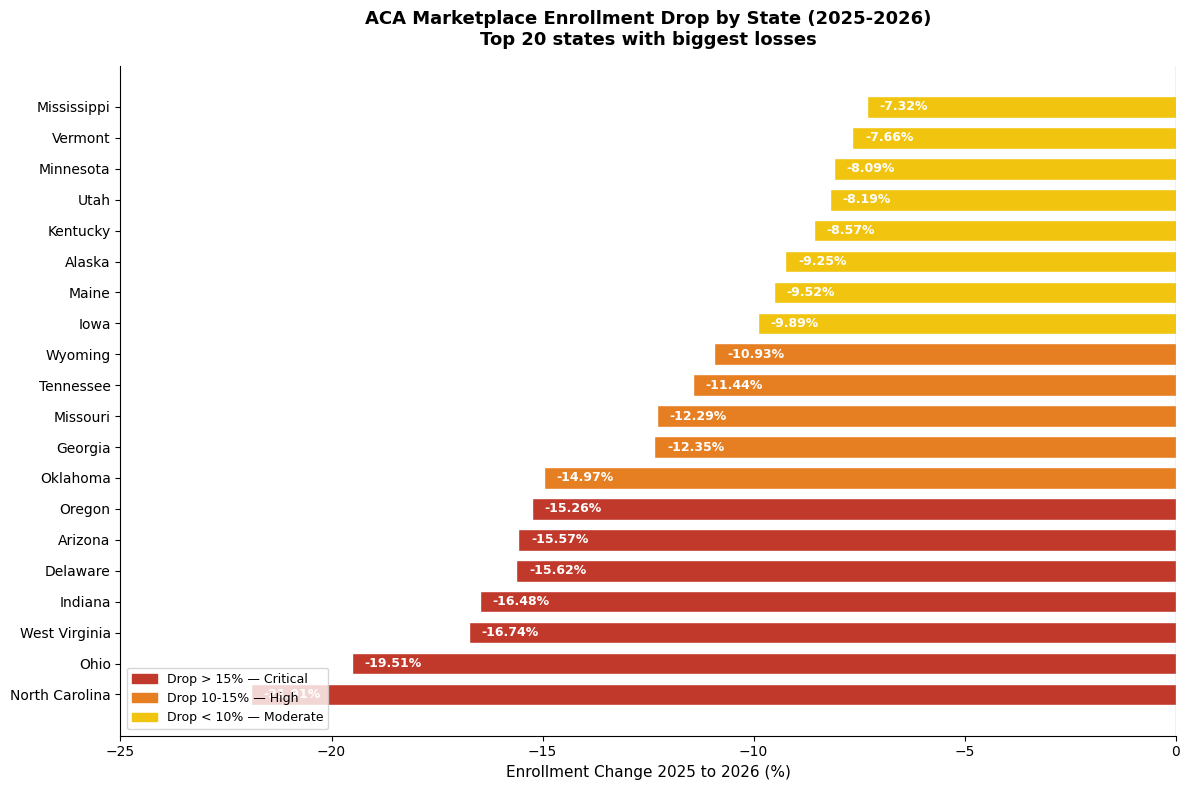

In [ ]:
top20_drop = master.sort_values('enrl_drop_pct').head(20)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#C0392B' if v <= -15 else '#E67E22' if v <= -10 else '#F1C40F'
          for v in top20_drop['enrl_drop_pct']]

bars = ax.barh(
    top20_drop['state_name'],
    top20_drop['enrl_drop_pct'],
    color=colors,
    edgecolor='white',
    height=0.7
)

# Labels sit inside the bar on the left side
for bar, val in zip(bars, top20_drop['enrl_drop_pct']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            str(val) + '%', va='center', ha='left',
            fontsize=9, color='white', fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#C0392B', label='Drop > 15% — Critical'),
    mpatches.Patch(color='#E67E22', label='Drop 10-15% — High'),
    mpatches.Patch(color='#F1C40F', label='Drop < 10% — Moderate'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9)

ax.set_xlabel('Enrollment Change 2025 to 2026 (%)', fontsize=11)
ax.set_title(
    'ACA Marketplace Enrollment Drop by State (2025-2026)\nTop 20 states with biggest losses',
    fontsize=13, fontweight='bold', pad=15
)

# Force x axis to show negative direction clearly
ax.set_xlim(-25, 0)
ax.axvline(0, color='black', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_enrollment_drop.png', dpi=150, bbox_inches='tight')
plt.show()


**11. Chart 2: Bronze shift**

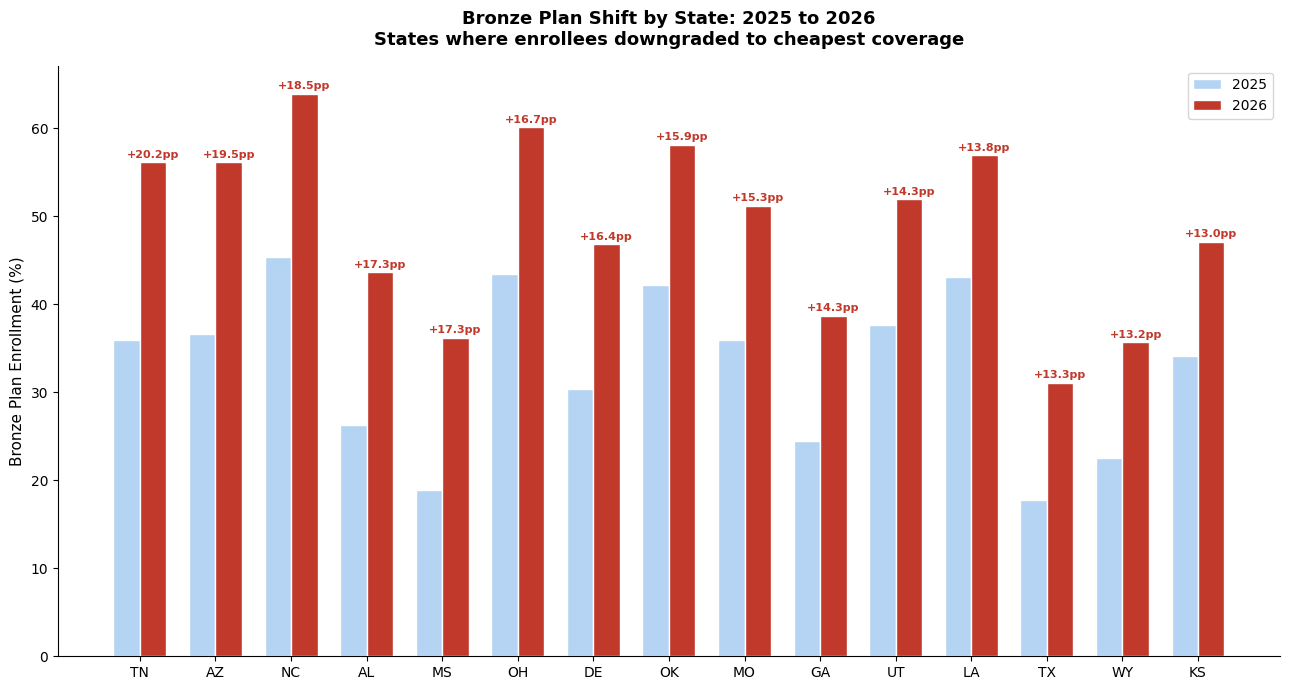

In [ ]:
top15_bronze = master.sort_values('bronze_shift', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 7))

x = range(len(top15_bronze))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], top15_bronze['bronze_pct_2025'],
               width, label='2025', color='#B5D4F4', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], top15_bronze['bronze_pct_2026'],
               width, label='2026', color='#C0392B', edgecolor='white')

for bar, shift in zip(bars2, top15_bronze['bronze_shift']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            '+' + str(shift) + 'pp', ha='center', fontsize=8,
            color='#C0392B', fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(top15_bronze['State_Abrvtn'], fontsize=10)
ax.set_ylabel('Bronze Plan Enrollment (%)', fontsize=11)
ax.set_title(
    'Bronze Plan Shift by State: 2025 to 2026\nStates where enrollees downgraded to cheapest coverage',
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_bronze_shift.png', dpi=150, bbox_inches='tight')
plt.show()


**12. Chart 3: APTC subsidy dependency**

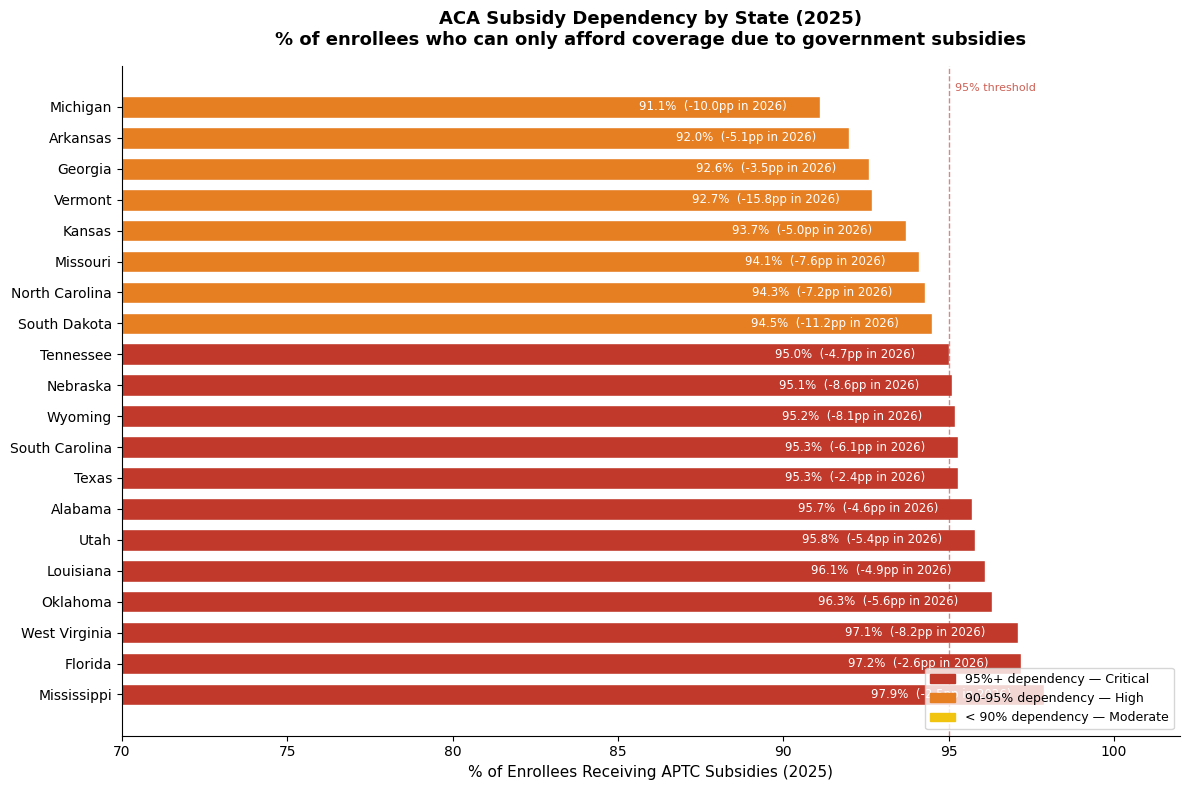

In [ ]:
top20_aptc = master.sort_values('aptc_rate_2025', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))

colors_aptc = ['#C0392B' if v >= 95 else '#E67E22' if v >= 90 else '#F1C40F'
               for v in top20_aptc['aptc_rate_2025']]

bars = ax.barh(
    top20_aptc['state_name'],
    top20_aptc['aptc_rate_2025'],
    color=colors_aptc,
    edgecolor='white',
    height=0.7
)

for bar, val, change in zip(bars, top20_aptc['aptc_rate_2025'], top20_aptc['aptc_change']):
    ax.text(bar.get_width() - 1, bar.get_y() + bar.get_height()/2,
            str(val) + '%  (' + str(change) + 'pp in 2026)',
            va='center', ha='right', fontsize=8.5, color='white')

ax.axvline(95, color='#C0392B', linewidth=1, linestyle='--', alpha=0.6)
ax.text(95.2, len(top20_aptc) - 0.5, '95% threshold',
        fontsize=8, color='#C0392B', alpha=0.8)

legend_patches = [
    mpatches.Patch(color='#C0392B', label='95%+ dependency — Critical'),
    mpatches.Patch(color='#E67E22', label='90-95% dependency — High'),
    mpatches.Patch(color='#F1C40F', label='< 90% dependency — Moderate'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

ax.set_xlabel('% of Enrollees Receiving APTC Subsidies (2025)', fontsize=11)
ax.set_xlim(70, 102)
ax.set_title(
    'ACA Subsidy Dependency by State (2025)\n% of enrollees who can only afford coverage due to government subsidies',
    fontsize=13, fontweight='bold', pad=15
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_aptc_dependency.png', dpi=150, bbox_inches='tight')
plt.show()


**13. Chart 4: Scatter plot APTC dependency vs enrollment drop**

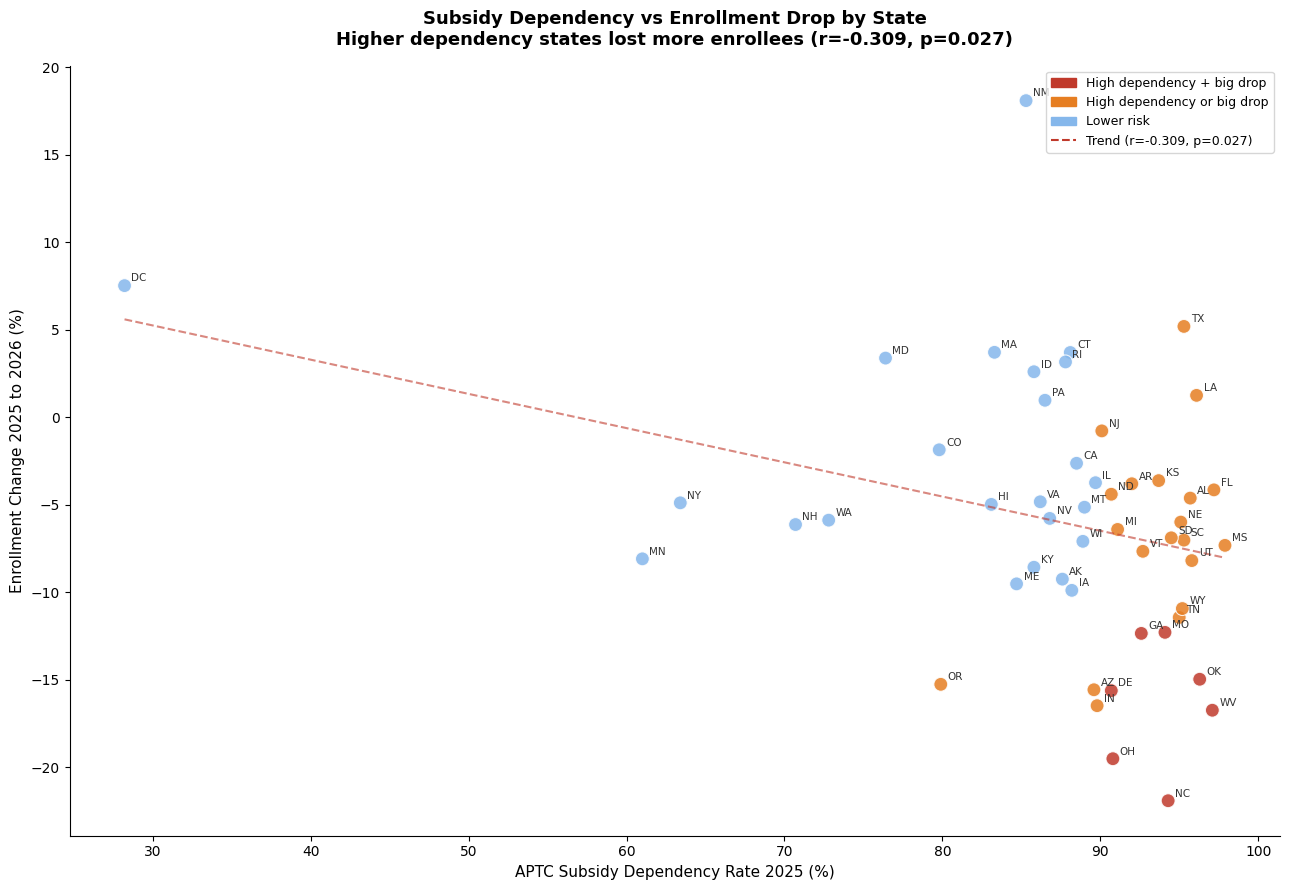

In [ ]:
from scipy import stats
import numpy as np

fig, ax = plt.subplots(figsize=(13, 9))

scatter_colors = [
    '#C0392B' if (a >= 90 and d <= -12) else
    '#E67E22' if (a >= 90 or d <= -12) else '#85B7EB'
    for a, d in zip(master['aptc_rate_2025'], master['enrl_drop_pct'])
]

ax.scatter(
    master['aptc_rate_2025'],
    master['enrl_drop_pct'],
    c=scatter_colors,
    s=100, alpha=0.85,
    edgecolors='white', linewidth=0.8
)

for _, row in master.iterrows():
    ax.annotate(
        row['State_Abrvtn'],
        (row['aptc_rate_2025'], row['enrl_drop_pct']),
        textcoords='offset points', xytext=(5, 3),
        fontsize=7.5, color='#333'
    )

# Trend line
clean = master[['aptc_rate_2025','enrl_drop_pct']].dropna()
m, b = np.polyfit(clean['aptc_rate_2025'], clean['enrl_drop_pct'], 1)
x_line = np.linspace(clean['aptc_rate_2025'].min(), clean['aptc_rate_2025'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#C0392B', linewidth=1.5,
        linestyle='--', alpha=0.6, label='Trend (r=-0.309, p=0.027)')

legend_patches = [
    mpatches.Patch(color='#C0392B', label='High dependency + big drop'),
    mpatches.Patch(color='#E67E22', label='High dependency or big drop'),
    mpatches.Patch(color='#85B7EB', label='Lower risk'),
]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0], color='#C0392B',
          linestyle='--', label='Trend (r=-0.309, p=0.027)')],
          loc='upper right', fontsize=9)

ax.set_xlabel('APTC Subsidy Dependency Rate 2025 (%)', fontsize=11)
ax.set_ylabel('Enrollment Change 2025 to 2026 (%)', fontsize=11)
ax.set_title(
    'Subsidy Dependency vs Enrollment Drop by State\nHigher dependency states lost more enrollees (r=-0.309, p=0.027)',
    fontsize=13, fontweight='bold', pad=15
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


**14. Chart 5: Financial stress context**

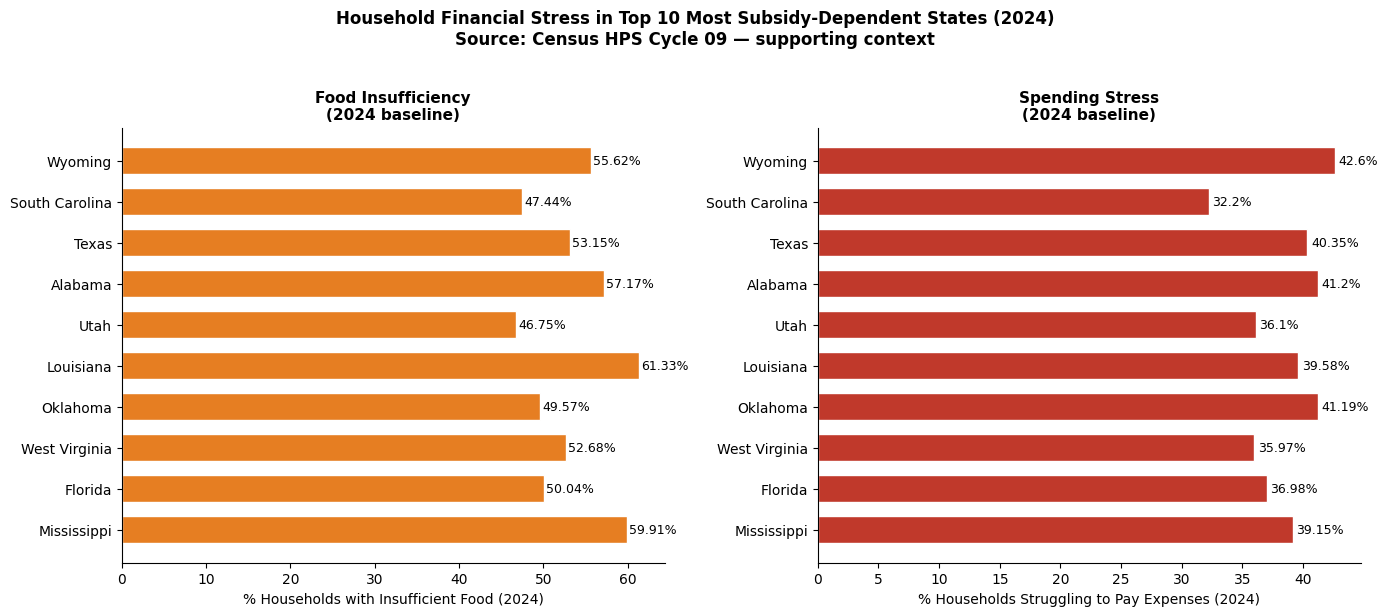

In [ ]:
top10_aptc = master.sort_values('aptc_rate_2025', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Food insufficiency
axes[0].barh(
    top10_aptc['state_name'],
    top10_aptc['food_insuff_pct'],
    color='#E67E22', edgecolor='white', height=0.65
)
axes[0].set_xlabel('% Households with Insufficient Food (2024)', fontsize=10)
axes[0].set_title('Food Insufficiency\n(2024 baseline)', fontsize=11, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for val, bar in zip(top10_aptc['food_insuff_pct'], axes[0].patches):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 str(val) + '%', va='center', fontsize=9)

# Spending stress
axes[1].barh(
    top10_aptc['state_name'],
    top10_aptc['spend_stress_pct'],
    color='#C0392B', edgecolor='white', height=0.65
)
axes[1].set_xlabel('% Households Struggling to Pay Expenses (2024)', fontsize=10)
axes[1].set_title('Spending Stress\n(2024 baseline)', fontsize=11, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for val, bar in zip(top10_aptc['spend_stress_pct'], axes[1].patches):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 str(val) + '%', va='center', fontsize=9)

fig.suptitle(
    'Household Financial Stress in Top 10 Most Subsidy-Dependent States (2024)\nSource: Census HPS Cycle 09 — supporting context',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('chart5_financial_stress_context.png', dpi=150, bbox_inches='tight')
plt.show()


**15.Export master CSV for Tableau**

In [ ]:
tableau_cols = [
    'State_Abrvtn', 'state_name',
    'Cnsmr_25', 'Cnsmr_26', 'enrl_lost', 'enrl_drop_pct',
    'aptc_rate_2025', 'aptc_rate_2026', 'aptc_change',
    'avg_prm_2025', 'avg_prm_2026', 'premium_change',
    'avg_prm_after_aptc_2025', 'avg_prm_after_aptc_2026', 'premium_after_aptc_change',
    'bronze_pct_2025', 'bronze_pct_2026', 'bronze_shift',
    'silver_pct_2025', 'silver_pct_2026', 'silver_shift',
    'rural_pct', 'low_income_pct',
    'new_enrollee_pct_2025', 'new_enrollee_pct_2026',
    'food_insuff_pct', 'spend_stress_pct'
]

final_export = master[tableau_cols].copy()
final_export.columns = [
    'state', 'state_name',
    'enrl_2025', 'enrl_2026', 'enrl_lost', 'enrl_drop_pct',
    'aptc_rate_2025', 'aptc_rate_2026', 'aptc_change',
    'avg_prm_2025', 'avg_prm_2026', 'premium_change',
    'avg_prm_after_aptc_2025', 'avg_prm_after_aptc_2026', 'premium_after_aptc_change',
    'bronze_pct_2025', 'bronze_pct_2026', 'bronze_shift',
    'silver_pct_2025', 'silver_pct_2026', 'silver_shift',
    'rural_pct', 'low_income_pct',
    'new_enrollee_pct_2025', 'new_enrollee_pct_2026',
    'food_insuff_pct', 'spend_stress_pct'
]

final_export.to_csv('aca_enrollment_master.csv', index=False)
print('Rows:', len(final_export))
print('Columns:', len(final_export.columns))
print()
print('Columns exported:')
for col in final_export.columns:
    print(' ', col)
print()


Rows: 51
Columns: 27

Columns exported:
  state
  state_name
  enrl_2025
  enrl_2026
  enrl_lost
  enrl_drop_pct
  aptc_rate_2025
  aptc_rate_2026
  aptc_change
  avg_prm_2025
  avg_prm_2026
  premium_change
  avg_prm_after_aptc_2025
  avg_prm_after_aptc_2026
  premium_after_aptc_change
  bronze_pct_2025
  bronze_pct_2026
  bronze_shift
  silver_pct_2025
  silver_pct_2026
  silver_shift
  rural_pct
  low_income_pct
  new_enrollee_pct_2025
  new_enrollee_pct_2026
  food_insuff_pct
  spend_stress_pct



**16. Download all output files**

In [ ]:
from google.colab import files

output_files = [
    'aca_enrollment_master.csv',
    'chart1_enrollment_drop.png',
    'chart2_bronze_shift.png',
    'chart3_aptc_dependency.png',
    'chart4_scatter.png',
    'chart5_financial_stress_context.png',
]

for f in output_files:
    try:
        files.download(f)
        print('Downloaded:', f)
    except Exception as e:
        print('Could not download', f, ':', e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: aca_enrollment_master.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: chart4_scatter.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: chart5_financial_stress_context.png


**Key Findings:**
1. National enrollment dropped 4.9% -- North Carolina lost 21.9% in one year
2. Bronze plan enrollment surged in states losing the most enrollees -- Tennessee shifted +20.2pp
3. 12 states have 95%+ subsidy dependency -- Mississippi at 97.9%
